# Problem Title - Library Mode
Issue: #<issue-number>1

## 1. Setup and Imports
Import only the required ML library tools and keep setup minimal and reproducible.

In [1]:
import torch
from torch import nn
import pandas as pd

In [2]:
# Set device agnostic
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## 2. Load and Inspect Data
Load dataset.csv and verify target column, feature types, and basic data quality checks.

In [ ]:
df = pd.read_csv("../dataset.csv")
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  quality_binary        6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [5]:
df['quality'].nunique(), df['quality_binary'].nunique()

(7, 2)

In [6]:
df.columns, len(df.columns)

(Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
        'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
        'pH', 'sulphates', 'alcohol', 'quality', 'quality_binary'],
       dtype='object'),
 13)

In [7]:
X = df[['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
        'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
        'pH', 'sulphates', 'alcohol']]

# For multi-class change from quality_binary to quality
# y = df['quality_binary']
y = df['quality']

X[:5], y[:5]

(   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
 0            7.4              0.70         0.00             1.9      0.076   
 1            7.8              0.88         0.00             2.6      0.098   
 2            7.8              0.76         0.04             2.3      0.092   
 3           11.2              0.28         0.56             1.9      0.075   
 4            7.4              0.70         0.00             1.9      0.076   
 
    free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
 0                 11.0                  34.0   0.9978  3.51       0.56   
 1                 25.0                  67.0   0.9968  3.20       0.68   
 2                 15.0                  54.0   0.9970  3.26       0.65   
 3                 17.0                  60.0   0.9980  3.16       0.58   
 4                 11.0                  34.0   0.9978  3.51       0.56   
 
    alcohol  
 0      9.4  
 1      9.8  
 2      9.8  
 3      9.8  
 4

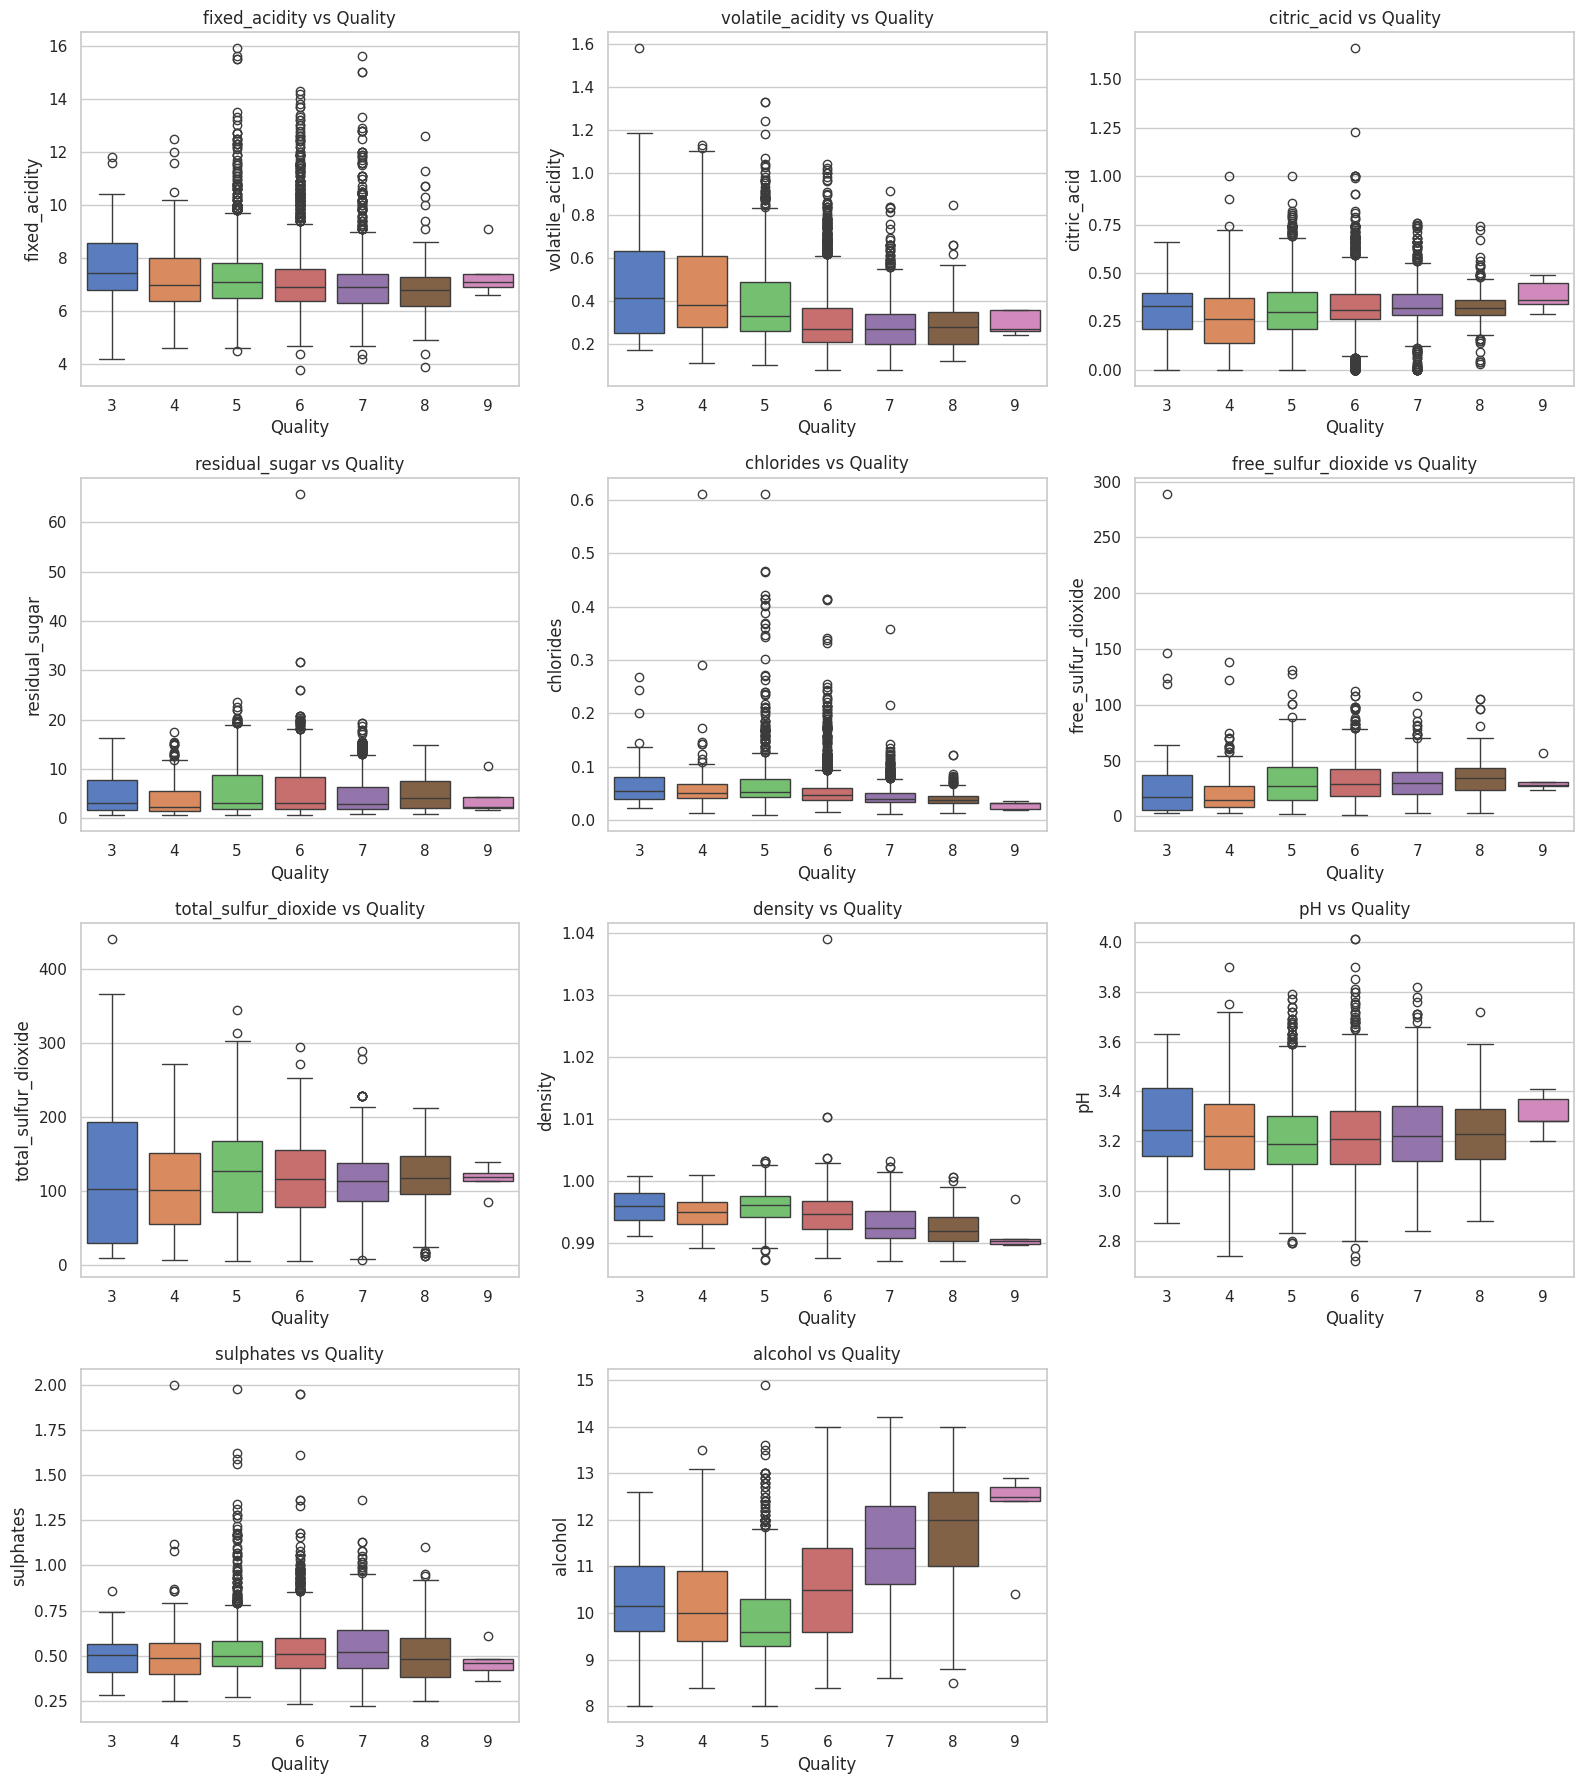

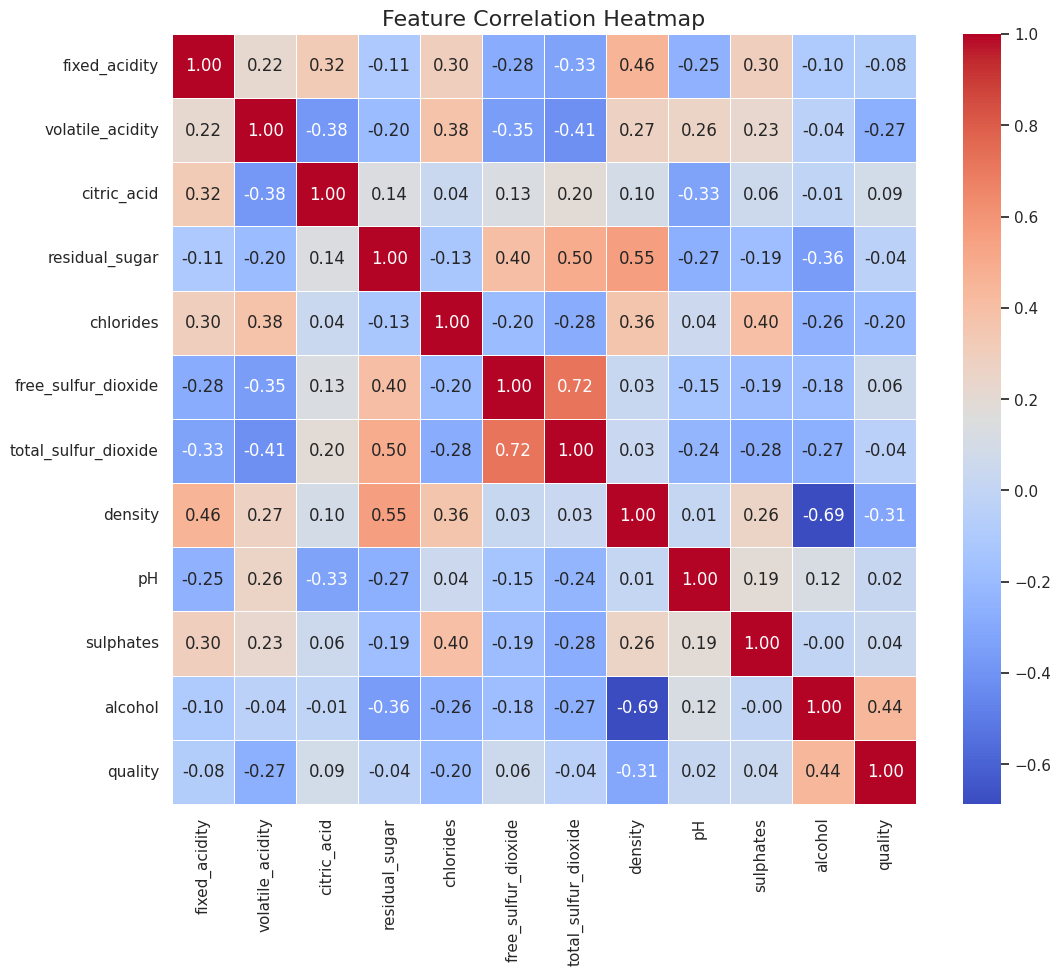

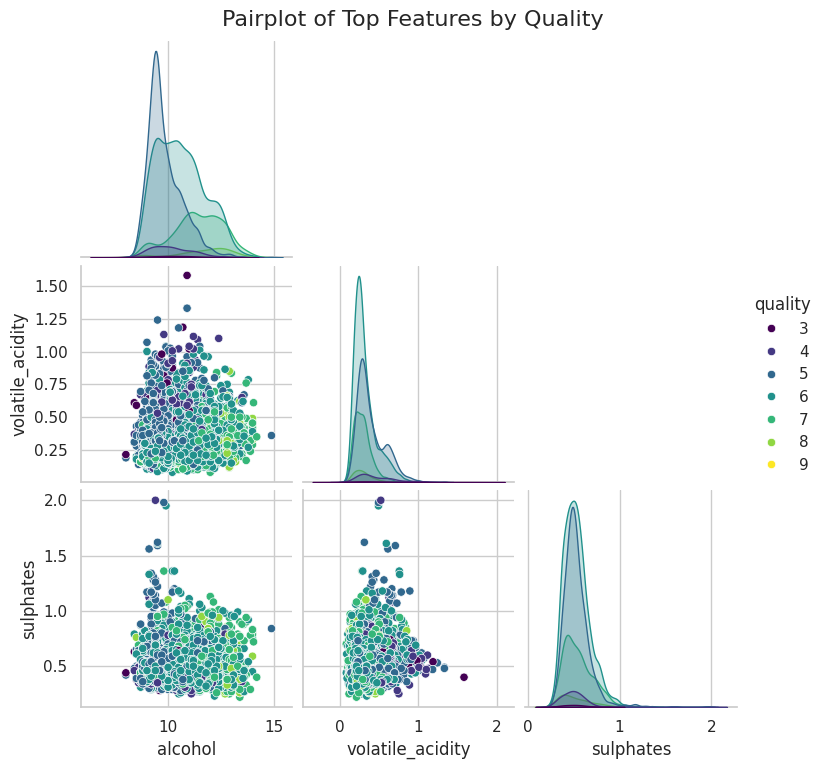

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for the plots
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Boxplots: Distribution of each feature by Quality
# ---------------------------------------------------------
# This creates a grid of boxplots so you can see exactly how
# the median and variance of each chemical property change
# across the different quality ratings.

features = X.columns
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    # Using the original df since y = df['quality']
    sns.boxplot(data=df, x='quality', y=col, ax=axes[i], palette="muted", hue='quality', legend=False)
    axes[i].set_title(f'{col} vs Quality', fontsize=12)
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel(col)

# Turn off the last empty subplot (since we have 11 features and 12 slots)
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Correlation Heatmap
# ---------------------------------------------------------
# This helps identify multicollinearity (features that are highly
# correlated with each other) and which features correlate most
# strongly with the target variable ('quality').

plt.figure(figsize=(12, 10))

# Combine X and y temporarily just for the correlation matrix
df_corr = X.copy()
df_corr['quality'] = y

# Calculate correlations and plot
correlation_matrix = df_corr.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

# ---------------------------------------------------------
# 3. Pairplot (Subset of Highly Correlated Features)
# ---------------------------------------------------------
# Plotting all 11 features in a pairplot creates a massive, unreadable 11x11 grid.
# It is better to select the top 3-4 features that the heatmap showed
# having the strongest correlation with 'quality' and pairplot those.
# (Replace the list below with your actual top features after viewing the heatmap)

top_features = ['alcohol', 'volatile_acidity', 'sulphates', 'quality']
sns.pairplot(df[top_features], hue='quality', palette='viridis', corner=True)
plt.suptitle('Pairplot of Top Features by Quality', y=1.02, fontsize=16)
plt.show()

## 3. Preprocessing
Apply only necessary preprocessing and avoid leakage by fitting transforms on train data only.

In [9]:
import numpy as np
import pandas as pd

# Assuming your features are currently in a DataFrame called 'X'
X_transformed = X.copy()

# 1. Calculate the skewness
skew_vals = X_transformed.skew()

# 2. Filter for features with a high skewness (threshold > 1.0 or < -1.0)
highly_skewed_features = skew_vals[abs(skew_vals) > 1.0].index.tolist()

print(f"Features identified for log transformation:\n{highly_skewed_features}\n")

# 3. Apply the log(1+x) transformation to those specific columns
for col in highly_skewed_features:
    X_transformed[col] = np.log1p(X_transformed[col])

# 4. Check the results to ensure the skewness has been fixed
print("New skewness values after transformation:")
print(X_transformed[highly_skewed_features].skew())

Features identified for log transformation:
['fixed_acidity', 'volatile_acidity', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'sulphates']

New skewness values after transformation:
fixed_acidity          0.976702
volatile_acidity       1.126873
residual_sugar         0.414917
chlorides              4.484421
free_sulfur_dioxide   -0.721434
sulphates              1.098588
dtype: float64


In [10]:
X_transformed.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,2.128232,0.530628,0.00,1.064711,0.073250,2.484907,34.0,0.9978,3.51,0.444686,9.4
1,2.174752,0.631272,0.00,1.280934,0.093490,3.258097,67.0,0.9968,3.20,0.518794,9.8
2,2.174752,0.565314,0.04,1.193922,0.088011,2.772589,54.0,0.9970,3.26,0.500775,9.8
3,2.501436,0.246860,0.56,1.064711,0.072321,2.890372,60.0,0.9980,3.16,0.457425,9.8
4,2.128232,0.530628,0.00,1.064711,0.073250,2.484907,34.0,0.9978,3.51,0.444686,9.4


In [11]:
X_data_tensor = torch.from_numpy(X_transformed.values).to(device)
y_data_tensor = torch.from_numpy(y.values).to(device)

X_data_tensor, y_data_tensor

(tensor([[ 2.1282,  0.5306,  0.0000,  ...,  3.5100,  0.4447,  9.4000],
         [ 2.1748,  0.6313,  0.0000,  ...,  3.2000,  0.5188,  9.8000],
         [ 2.1748,  0.5653,  0.0400,  ...,  3.2600,  0.5008,  9.8000],
         ...,
         [ 2.0149,  0.2151,  0.1900,  ...,  2.9900,  0.3784,  9.4000],
         [ 1.8718,  0.2546,  0.3000,  ...,  3.3400,  0.3221, 12.8000],
         [ 1.9459,  0.1906,  0.3800,  ...,  3.2600,  0.2776, 11.8000]],
        dtype=torch.float64),
 tensor([5, 5, 5,  ..., 6, 7, 6]))

In [12]:
X_data_tensor.shape, y_data_tensor.shape

(torch.Size([6497, 11]), torch.Size([6497]))

In [13]:
y_data_tensor.min().item()

3

In [14]:
# Subtracting by the minimum so that the labels are from 0 to n-1
# IF we don't do this we get the error: Target 7 is out of bounds.
new_y_tensor = y_data_tensor - y_data_tensor.min().item()

In [15]:
new_y_tensor.unique()

tensor([0, 1, 2, 3, 4, 5, 6])

In [16]:
X_min = X_data_tensor.min()
X_max = X_data_tensor.max()
X_min, X_max

(tensor(0., dtype=torch.float64), tensor(440., dtype=torch.float64))

In [17]:
X_scaled = (X_data_tensor - X_min) / (X_max - X_min)
X_scaled

tensor([[4.8369e-03, 1.2060e-03, 0.0000e+00,  ..., 7.9773e-03, 1.0106e-03,
         2.1364e-02],
        [4.9426e-03, 1.4347e-03, 0.0000e+00,  ..., 7.2727e-03, 1.1791e-03,
         2.2273e-02],
        [4.9426e-03, 1.2848e-03, 9.0909e-05,  ..., 7.4091e-03, 1.1381e-03,
         2.2273e-02],
        ...,
        [4.5793e-03, 4.8889e-04, 4.3182e-04,  ..., 6.7955e-03, 8.6008e-04,
         2.1364e-02],
        [4.2541e-03, 5.7873e-04, 6.8182e-04,  ..., 7.5909e-03, 7.3201e-04,
         2.9091e-02],
        [4.4225e-03, 4.3323e-04, 8.6364e-04,  ..., 7.4091e-03, 6.3098e-04,
         2.6818e-02]], dtype=torch.float64)

In [18]:
X_scaled[0]

tensor([0.0048, 0.0012, 0.0000, 0.0024, 0.0002, 0.0056, 0.0773, 0.0023, 0.0080,
        0.0010, 0.0214], dtype=torch.float64)

In [19]:
X_data_tensor[0], y_data_tensor[0]

(tensor([ 2.1282,  0.5306,  0.0000,  1.0647,  0.0733,  2.4849, 34.0000,  0.9978,
          3.5100,  0.4447,  9.4000], dtype=torch.float64),
 tensor(5))

In [20]:
input_shape = X_data_tensor[0].shape[0]
output_shape = df['quality'].nunique()
input_shape, output_shape

(11, 7)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, new_y_tensor, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

(tensor([[4.6094e-03, 4.8889e-04, 7.9545e-04,  ..., 7.2500e-03, 7.1548e-04,
          2.3864e-02],
         [5.0682e-03, 5.6105e-04, 1.0909e-03,  ..., 7.4091e-03, 1.0964e-03,
          2.8182e-02],
         [4.9166e-03, 1.2259e-03, 2.2727e-05,  ..., 7.7500e-03, 1.0252e-03,
          2.6818e-02],
         ...,
         [4.5488e-03, 7.1548e-04, 4.5455e-04,  ..., 7.3636e-03, 8.1290e-04,
          2.1591e-02],
         [4.5793e-03, 5.2525e-04, 1.1364e-03,  ..., 7.2273e-03, 8.7560e-04,
          2.1591e-02],
         [4.7821e-03, 1.0964e-03, 1.3636e-04,  ..., 7.9773e-03, 9.8132e-04,
          2.1591e-02]], dtype=torch.float64),
 tensor([[0.0047, 0.0004, 0.0017,  ..., 0.0074, 0.0007, 0.0277],
         [0.0049, 0.0011, 0.0005,  ..., 0.0074, 0.0008, 0.0225],
         [0.0047, 0.0007, 0.0008,  ..., 0.0072, 0.0008, 0.0273],
         ...,
         [0.0046, 0.0003, 0.0008,  ..., 0.0072, 0.0013, 0.0282],
         [0.0046, 0.0007, 0.0009,  ..., 0.0075, 0.0010, 0.0214],
         [0.0048, 0.0003, 0.00

In [22]:
X_train.shape, y_train.shape

(torch.Size([5197, 11]), torch.Size([5197]))

## 4. Model Setup
Define the model and key hyperparameters, and set random_state where available.

In [32]:
class Model(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  def forward(self, x):
    return self.block_1(x)

In [41]:
model = Model(input_shape=input_shape, hidden_units=32, output_shape=output_shape).to(device)
model

Model(
  (block_1): Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)

## 5. Training
Fit on train split and keep training flow clear so outputs are easy to review.

In [42]:
try:
  import torchmetrics
except:
  !pip install torchmetrics
  import torchmetrics

In [43]:
# Set the loss function, accuracy function, f1-score and optimizer
from torchmetrics import Accuracy, F1Score

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.01)
accuracy_fn = Accuracy(task='multiclass', num_classes=output_shape)
f1_score = F1Score(task='multiclass', num_classes=output_shape)

In [44]:
y_train.unique()

tensor([0, 1, 2, 3, 4, 5, 6])

In [45]:
# Training Loop
epochs = 500

X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)
X_train, X_test = X_train.to(torch.float32), X_test.to(torch.float32)

train_accuracies = []
test_accuracies = []
train_losses = []
test_losses = []
epoch_count = []
f1_scores = []

for epoch in range(epochs):
  # set the mode to train
  model.train()

  y_logits = model(X_train)
  y_pred_prob = torch.softmax(y_logits, dim=1)
  y_pred_label = torch.argmax(y_pred_prob, dim=1)

  # calculate the loss and accuracy
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_pred_label, y_train)

  # Optimizer zero grad
  optimizer.zero_grad()

  # Backpropagation
  loss.backward()

  # Optimizer step
  optimizer.step()

  # Testing loop
  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test)
    test_pred_label = torch.argmax(torch.softmax(test_logits, dim=1), dim=1)

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(test_pred_label, y_test)
    f1 = f1_score(test_pred_label, y_test)

  if epoch % 100 == 0:
    epoch_count.append(epoch)
    train_accuracies.append(acc.item())
    test_accuracies.append(test_acc.item())
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    f1_scores.append(f1.item())


    print(f"Epoch : {epoch} | Loss : {loss:.3f} | Test Loss : {test_loss:.3f} | Accuracy : {acc:.2f}% | Test Accuracy : {test_acc:.2f}% | F1-Score : {f1:.3f}")

Epoch : 0 | Loss : 1.961 | Test Loss : 1.912 | Accuracy : 0.17% | Test Accuracy : 0.17% | F1-Score : 0.165
Epoch : 100 | Loss : 1.265 | Test Loss : 1.264 | Accuracy : 0.44% | Test Accuracy : 0.45% | F1-Score : 0.447
Epoch : 200 | Loss : 1.248 | Test Loss : 1.243 | Accuracy : 0.44% | Test Accuracy : 0.45% | F1-Score : 0.454
Epoch : 300 | Loss : 1.171 | Test Loss : 1.168 | Accuracy : 0.50% | Test Accuracy : 0.49% | F1-Score : 0.485
Epoch : 400 | Loss : 1.112 | Test Loss : 1.114 | Accuracy : 0.54% | Test Accuracy : 0.53% | F1-Score : 0.529


In [46]:
train_accuracies

[0.16624975204467773,
 0.4412160813808441,
 0.4412160813808441,
 0.4952857494354248,
 0.5381951332092285]

## 6. Evaluation
Report labeled train and test metrics clearly and compare against acceptance threshold.

In [47]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'f1 Score')

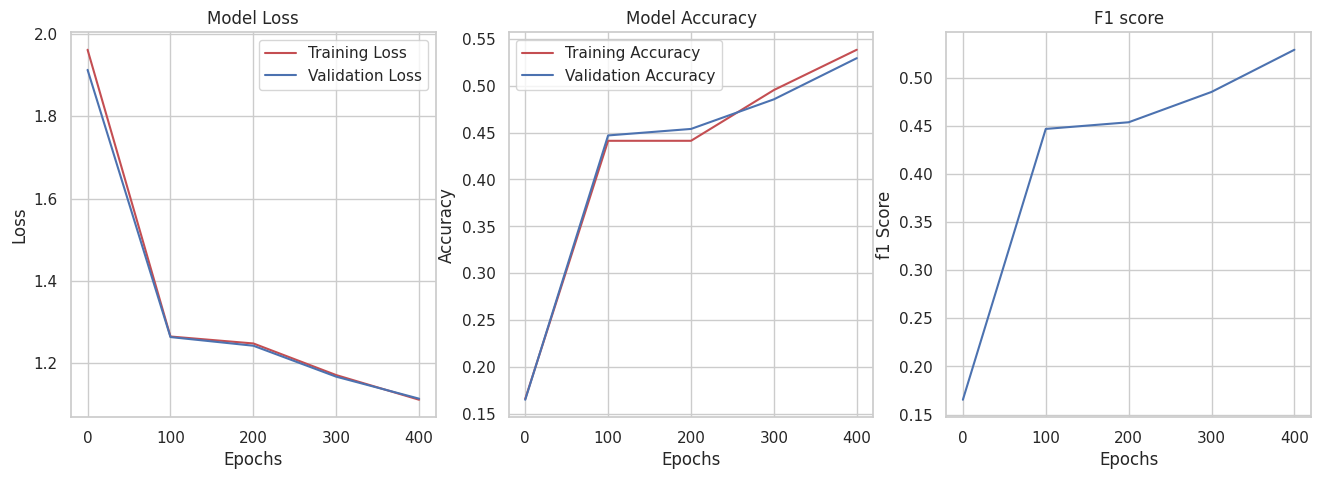

In [52]:
# Loss Curve
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.plot(epoch_count, train_losses, 'r', label='Training Loss')
plt.plot(epoch_count, test_losses, 'b', label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Curve
plt.subplot(1, 3, 2)
plt.plot(epoch_count, train_accuracies, 'r', label='Training Accuracy')
plt.plot(epoch_count, test_accuracies, 'b', label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# F1 Curve
plt.subplot(1, 3, 3)
plt.plot(epoch_count, f1_scores, 'b')
plt.title('F1 score')
plt.xlabel('Epochs')
plt.ylabel('f1 Score')

## 7. Interpretation
Answer only these library-training questions:
1. Which preprocessing step had the biggest impact on this model's performance?
2. What do train vs test metrics say about fit quality (underfit/overfit/good fit)?
3. Which library model/hyperparameter choice influenced results the most, based on your outputs?

Ans 1) I didn't really remove any features from the dataset as it was a small dataset and it doesn't really seem necessary. I applied log transformation on the highly skewed feature but it didn't changed the result that much and i also scaled all the features between 0 and 1 (min-max scaling). Most of these changes didn't really seem to affect the model's prediction.

Ans 2) The model seems to be fitting quite well even though the accuracy is around 50%. But based on the given data, it's natural to recieve this kind of result.

Ans 3) Choosing the right learning rate influenced the result the most as when i used 0.01, the model was able to learn properly. And also setting the number of hidden_units to 32 made the model better at getting an understanding of the pattern.